In [100]:
import pandas as pd
import forestplot as fp
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll


In [101]:
df = pd.read_csv('source/predictors_satisfaction.csv')
df2 = pd.read_csv('source/predictors_frequency_alignment.csv')
df3 = pd.read_csv('source/predictors_desire_alignment.csv')

In [102]:
df.head(3)

,Predictors,AOR,Lower CI,Upper CI,p-value,Category,err_lower,err_upper
0,Age,1.015701,1.007115,1.024359,0.000322,Sociodemographic,0.008586,0.008659
1,Work Status,1.144168,1.071742,1.221488,0.000054,Sociodemographic,0.072426,0.077320
2,Extraversion,0.980780,0.958630,1.003441,0.095872,Personality Traits,0.022150,0.022662


In [103]:
def get_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''
df['Significance'] = df['p-value'].apply(get_stars)
df2['Significance'] = df2['p-value'].apply(get_stars)
df3['Significance'] = df3['p-value'].apply(get_stars)

In [104]:
df['p-value-t'] = df['p-value'].apply(lambda x: f'{x:.3f}')
df2['p-value-t'] = df2['p-value'].apply(lambda x: f'{x:.3f}')
df3['p-value-t'] = df3['p-value'].apply(lambda x: f'{x:.3f}')

In [105]:
def get_colors(p):
    if p < 0.05:
        return '#1f77b4'
    else:
        return '#bcbd22'
df['Color'] = df['p-value'].apply(get_colors)

In [106]:
# df = df.reset_index(drop=True)

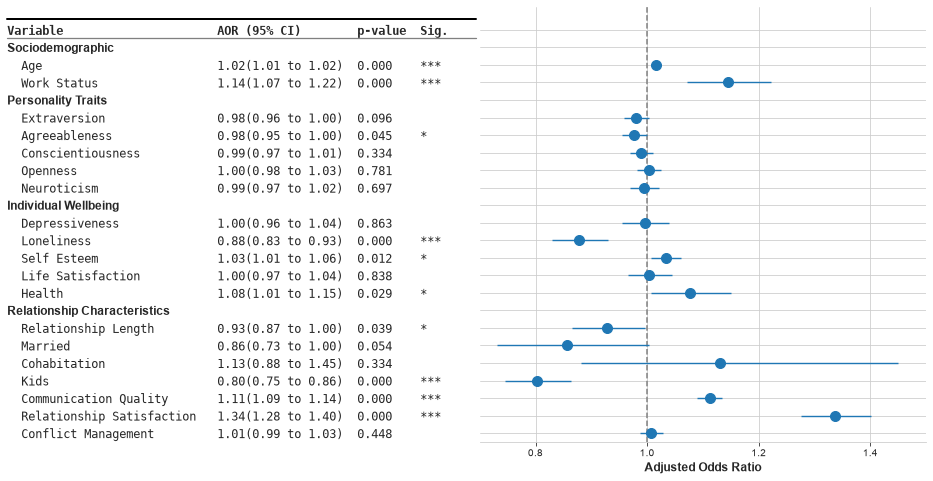

In [107]:
ax = fp.forestplot(
    df,
    estimate="AOR",
    ll="Lower CI", hl="Upper CI",
    varlabel="Predictors",
    xlabel="Adjusted Odds Ratio",
    groupvar="Category",
    decimal_precision=2,
    color_alt_rows=False,
    annote=["est_ci", "p-value-t", "Significance"],
    annoteheaders=["AOR (95% CI)", "p-value", "Sig.    "],
    # extra space in the last header to add some padding to the plot
    figsize=(8, 8),
    table=True,
    **{
        'fontfamily': 'DejaVu Sans Mono',
        'ylabel1_size': 12,

        'marker': 'o',
        'markersize': 100,
        'markercolor': '#1f77b4',

        'linecolor': '#1f77b4',
        'linestyle': '-',
    },
    xlim=(0.7, 1.5),

)

for collection in ax.collections:
    print(collection)
    if isinstance(collection, mcoll.PathCollection):
        collection.set_zorder(10)  # A high number forces it to the top layer
        collection.set_alpha(1.0)
    elif isinstance(collection, mcoll.LineCollection):
        collection.set_zorder(10)  # A high number forces it to the top layer
        collection.set_alpha(1.0)

ax.axvline(x=1, color='grey', linestyle='--', linewidth=1.5)

plt.savefig("output/img/alignment/alignment_forest.png", dpi=300, bbox_inches='tight')
plt.show()

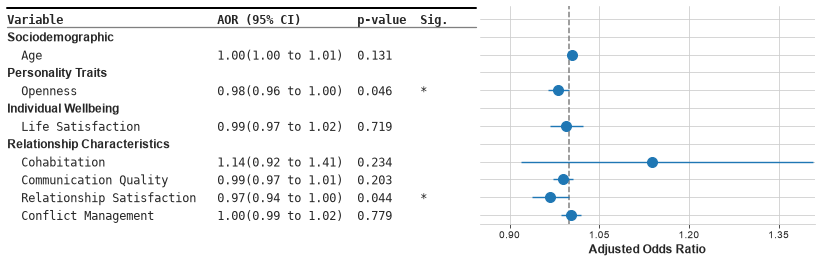

In [110]:
ax2 = fp.forestplot(
    df2,
    estimate="AOR",
    ll="Lower CI", hl="Upper CI",
    varlabel="Predictors",
    # ylabel="Est.(95% Conf. Int.)",
    xlabel="Adjusted Odds Ratio",
    groupvar="Category",
    # pval="p-value",
    decimal_precision=2,
    color_alt_rows=False,
    annote=["est_ci", "p-value-t", "Significance"],
    annoteheaders=["AOR (95% CI)", "p-value", "Sig.    "],
    figsize=(6, 4),
    table=True,

    **{
        'fontfamily': 'DejaVu Sans Mono',
        'ylabel1_size': 12,

        'marker': 'o',
        'markersize': 100,
        'markercolor': '#1f77b4',

        'linecolor': '#1f77b4',
        'linestyle': '-',
    },
    xlim=(0.85, 1.41),
)

for collection in ax2.collections:
    print(collection)
    if isinstance(collection, mcoll.PathCollection):
        collection.set_zorder(10)  # A high number forces it to the top layer
        collection.set_alpha(1.0)
    elif isinstance(collection, mcoll.LineCollection):
        collection.set_zorder(10)  # A high number forces it to the top layer
        collection.set_alpha(1.0)
ax2.axvline(x=1, color='grey', linestyle='--', linewidth=1.5)

plt.savefig("output/img/alignment/alignment_forest_frequency.png", dpi=300, bbox_inches='tight')

plt.show()

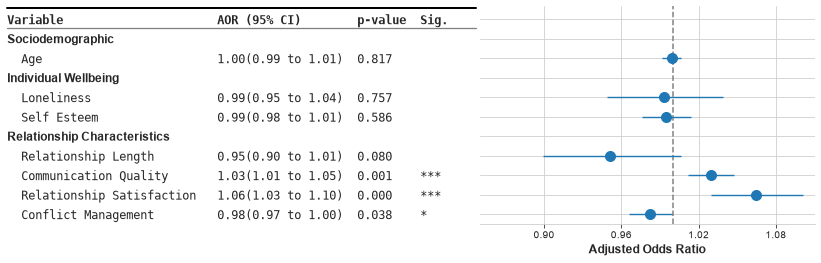

In [112]:
ax3 = fp.forestplot(
   df3,
    estimate="AOR",
    ll="Lower CI", hl="Upper CI",
    varlabel="Predictors",
    # ylabel="Est.(95% Conf. Int.)",
    xlabel="Adjusted Odds Ratio",
    groupvar="Category",
    # pval="p-value",
    decimal_precision=2,
    color_alt_rows=False,
    annote=["est_ci", "p-value-t", "Significance"],
    annoteheaders=["AOR (95% CI)", "p-value", "Sig.    "],
    figsize=(6, 4),
    table=True,

    **{
        'fontfamily': 'DejaVu Sans Mono',
        'ylabel1_size': 12,

        'marker': 'o',
        'markersize': 100,
        'markercolor': '#1f77b4',

        'linecolor': '#1f77b4',
        'linestyle': '-',
    },
    xlim=(0.85, 1.11),
)

for collection in ax3.collections:
    print(collection)
    if isinstance(collection, mcoll.PathCollection):
        collection.set_zorder(10)  # A high number forces it to the top layer
        collection.set_alpha(1.0)
    elif isinstance(collection, mcoll.LineCollection):
        collection.set_zorder(10)  # A high number forces it to the top layer
        collection.set_alpha(1.0)
ax3.axvline(x=1, color='grey', linestyle='--', linewidth=1.5)

plt.savefig("output/img/alignment/alignment_forest_desire.png",dpi=300, bbox_inches='tight')

plt.show()